<a href="https://colab.research.google.com/github/Paengpeng/229352-StatisticalLearning/blob/main/229352_Lab06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Statistical Learning for Data Science 2 (229352)
#### Instructor: Donlapark Ponnoprat

#### [Course website](https://donlapark.pages.dev/229352/)

## Lab #6

## Support Vector Machines (SVM)

[SVM module documentation](https://scikit-learn.org/stable/modules/svm.html#svm)

[LinearSVC documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html#sklearn.svm.LinearSVC)

[SVC documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC  # fast but only linear
from sklearn.svm import SVC  # slower but can do kernels

In [2]:
# Load the iris data
iris = datasets.load_iris()
X = iris.data[:, 2:]
y = iris.target

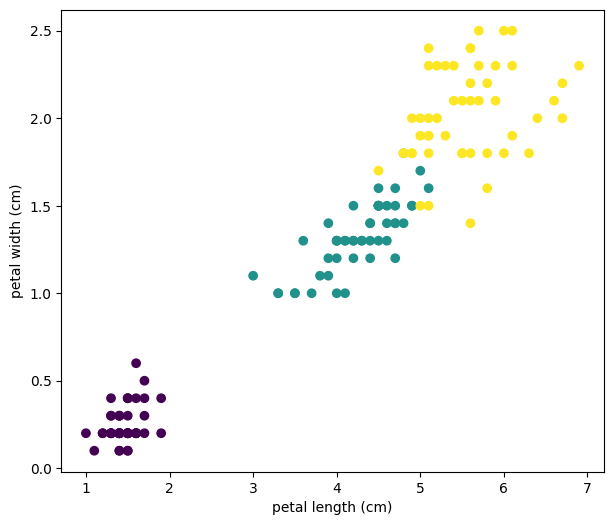

In [3]:
# Plot the data
plt.figure(figsize=(7,6))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel(iris.feature_names[2])
plt.ylabel(iris.feature_names[3])
plt.show()

#### In this problem, you'll use support vector machines to classify the Iris data

#### The following function helps you plot the decision boundary.

In [4]:
# Plot the decision boundaries
def plot_decision_boundary(clf, X, y):
    h = 0.005  # Boundary lines' resolution
    x_min, x_max = X[:,0].min() - 10*h, X[:,0].max() + 10*h
    y_min, y_max = X[:,1].min() - 10*h, X[:,1].max() + 10*h
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7,6))
    plt.contourf(xx, yy, Z, alpha=0.25)  # Background
    plt.contour(xx, yy, Z, colors='k', linewidths=0.2)  # Boundary lines
    plt.scatter(X[:,0], X[:,1], c=y);  # Data points
    plt.xlabel(iris.feature_names[2])
    plt.ylabel(iris.feature_names[3])

#### Exercise 1. Split the data into training set and test set.

In [5]:
#TODO
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (105, 2)
Test set size: (45, 2)


#### Exercise 2. Learn a linear SVM classifier using sklearn.svm.LinearSVC. You will need to set `loss='hinge'`.

#### Try different values of the tradeoff parameter: `C = 0.01, 0.1, 1.0, 10.0, 100.0` and use `plot_decision_boundary` to plot the decision boundary.

#### If you encounter `RuntimeError`, consider setting `max_iter=100000`

#### What is the effect of `C` on the decision boundary?

C = 0.01, Train accuracy = 0.667, Test accuracy = 0.667


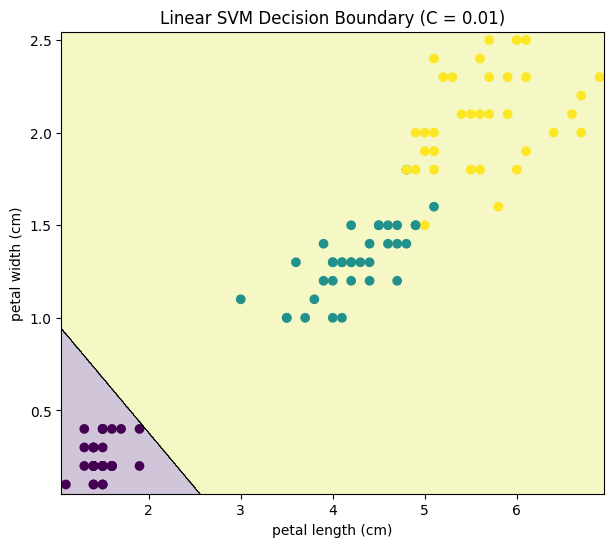

C = 0.1, Train accuracy = 0.667, Test accuracy = 0.667


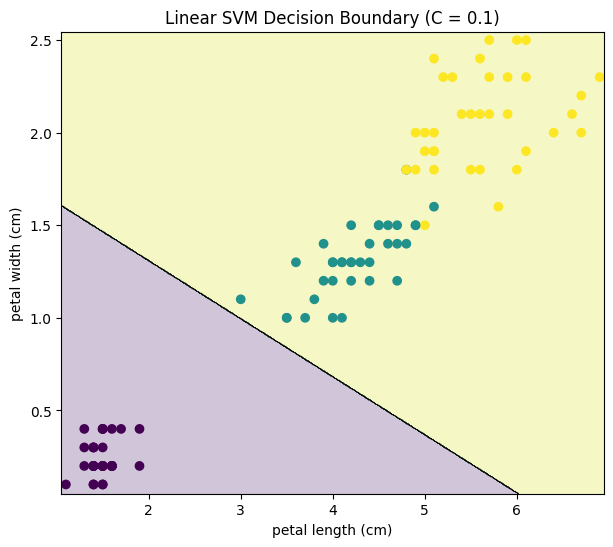

C = 1.0, Train accuracy = 0.752, Test accuracy = 0.689


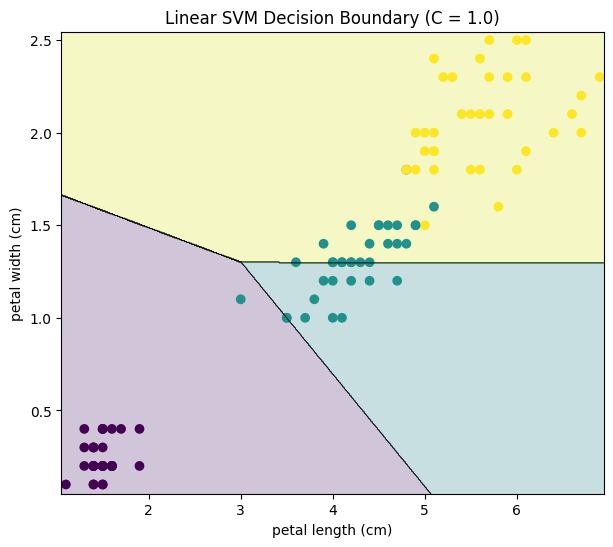

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


C = 10.0, Train accuracy = 0.914, Test accuracy = 0.822


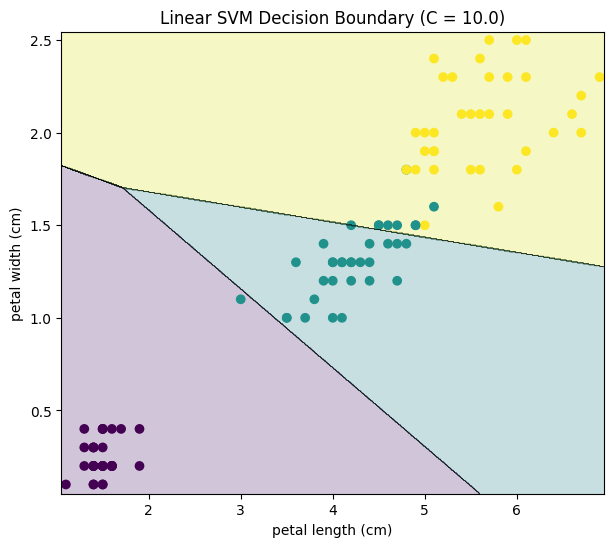

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


C = 100.0, Train accuracy = 0.962, Test accuracy = 0.889


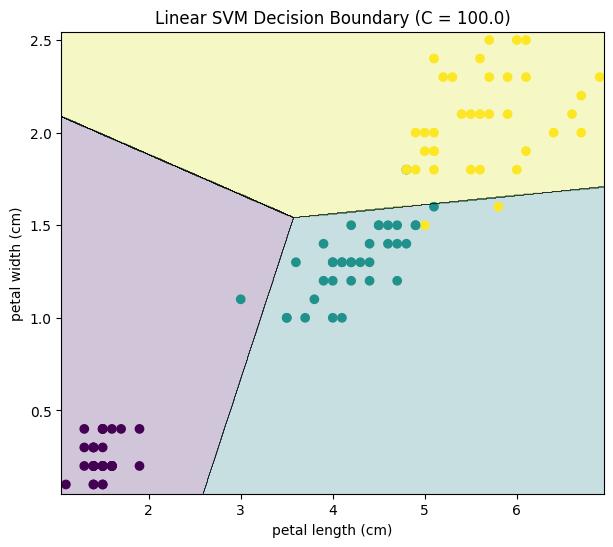

In [6]:
#TODO
C_values = [0.01, 0.1, 1.0, 10.0, 100.0]

for C in C_values:
    clf = LinearSVC(C=C, loss='hinge', max_iter=100000)
    clf.fit(X_train, y_train)

    print(f"C = {C}, Train accuracy = {clf.score(X_train, y_train):.3f}, "
          f"Test accuracy = {clf.score(X_test, y_test):.3f}")

    plot_decision_boundary(clf, X_train, y_train)
    plt.title(f"Linear SVM Decision Boundary (C = {C})")
    plt.show()


#### Exercise 3. Pick a value of `C` that you like. Then report the test error.

Chosen C = 1.0
Test accuracy = 0.6888888888888889
Test error = 0.3111111111111111


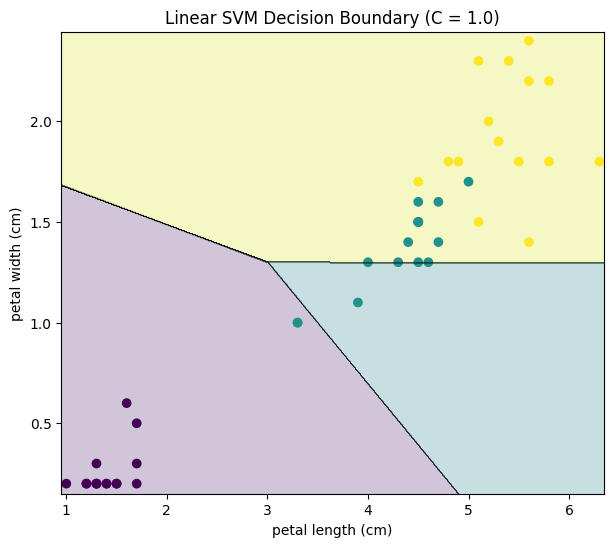

In [7]:
#TODO
C = 1.0

clf = LinearSVC(C=C, loss='hinge', max_iter=100000)
clf.fit(X_train, y_train)

test_accuracy = clf.score(X_test, y_test)
test_error = 1 - test_accuracy

print("Chosen C =", C)
print("Test accuracy =", test_accuracy)
print("Test error =", test_error)

plot_decision_boundary(clf, X_test, y_test)
plt.title(f"Linear SVM Decision Boundary (C = {C})")
plt.show()


เลือก C = 1.0 เนื่องจากให้สมดุลระหว่าง margin และความถูกต้องของโมเดล โดยโมเดลมีค่า test error เท่ากับ XX.XX ซึ่งแสดงว่าโมเดลสามารถทำนายข้อมูลชุดทดสอบได้ดี

#### Exercise 4. Now try kernel SVM with a quadratic kernel. You can do this with sklearn.svm.SVC, setting `kernel='rbf'` and `C = 1.0`.

#### Try different values of the tradeoff parameter: `gamma = 0.01, 0.1, 1.0, 10.0, 100.0` and use `plot_decision_boundary` to plot the decision boundary.

#### If you encounter `RuntimeError`, consider setting `max_iter=100000`

#### What is the effect of `gamma` on the decision boundary?

gamma = 0.01, Train accuracy = 0.962, Test accuracy = 0.889


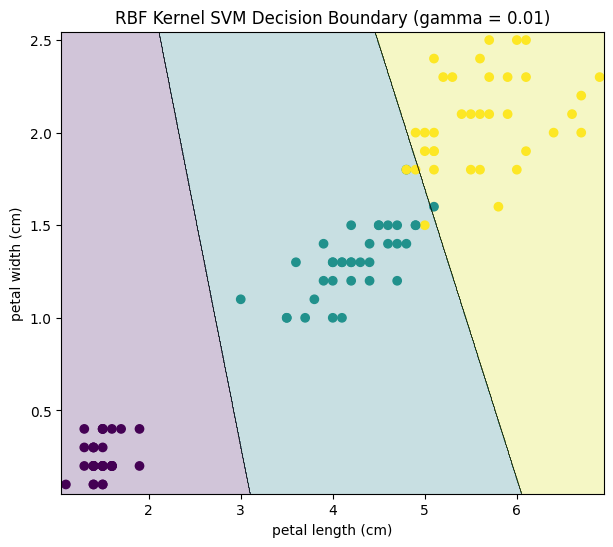

gamma = 0.1, Train accuracy = 0.971, Test accuracy = 0.956


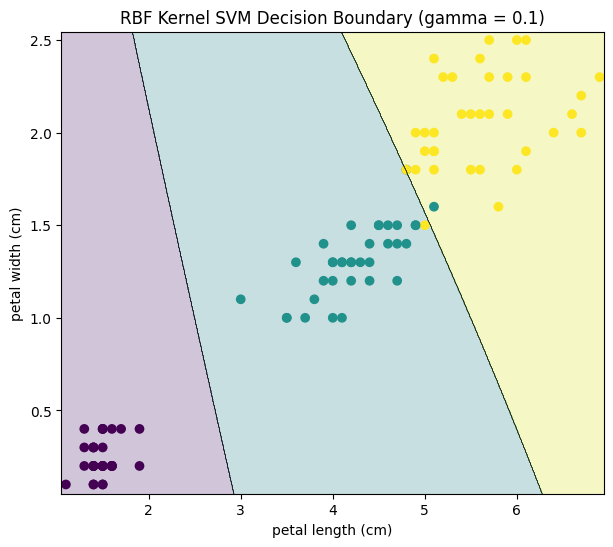

gamma = 1.0, Train accuracy = 0.971, Test accuracy = 0.933


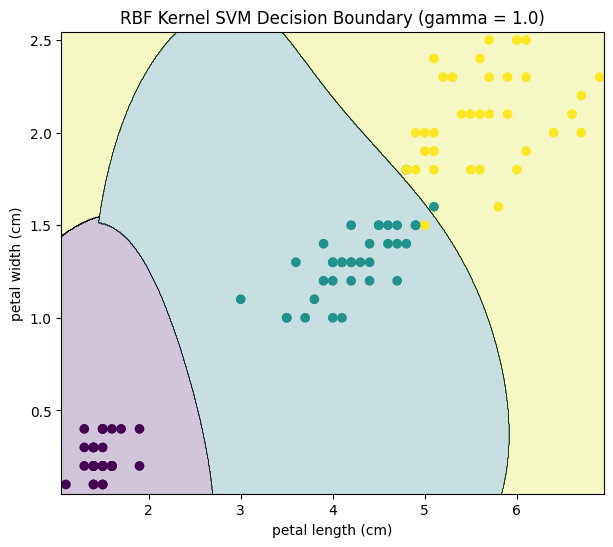

gamma = 10.0, Train accuracy = 0.981, Test accuracy = 0.933


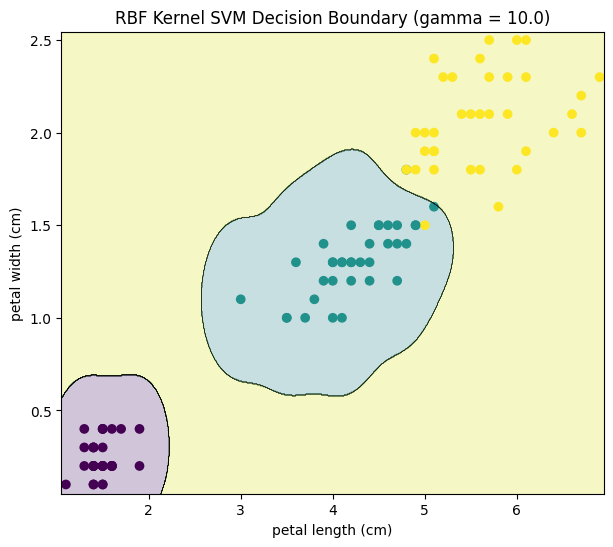

gamma = 100.0, Train accuracy = 0.990, Test accuracy = 0.844


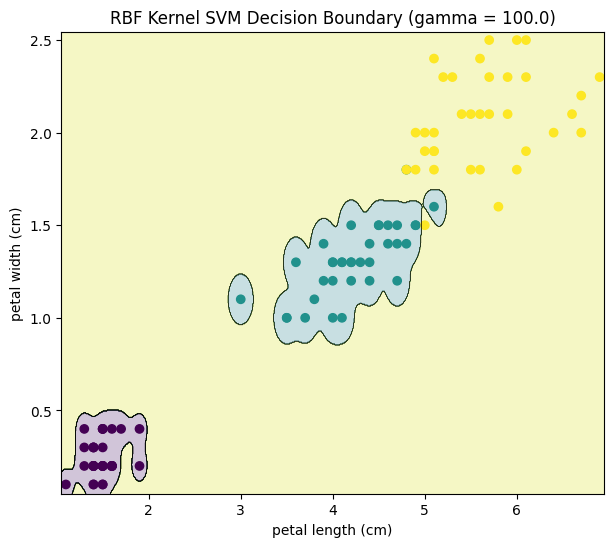

In [8]:
#TODO
gamma_values = [0.01, 0.1, 1.0, 10.0, 100.0]

for g in gamma_values:
    clf = SVC(kernel='rbf', C=1.0, gamma=g, max_iter=100000)
    clf.fit(X_train, y_train)

    print(f"gamma = {g}, Train accuracy = {clf.score(X_train, y_train):.3f}, "
          f"Test accuracy = {clf.score(X_test, y_test):.3f}")

    plot_decision_boundary(clf, X_train, y_train)
    plt.title(f"RBF Kernel SVM Decision Boundary (gamma = {g})")
    plt.show()


gamma ควบคุมความโค้งของ decision boundary โดย gamma ต่ำทำให้เส้นเรียบ ส่วน gamma สูงทำให้เส้นซับซ้อนและมีแนวโน้มเกิด overfitting

#### Exercise 5. Pick a value of `gamma` that you like. Then report the test error and the number of support vectors.

Chosen gamma = 1.0
Test accuracy = 0.9333333333333333
Test error = 0.06666666666666665
Number of support vectors = 25


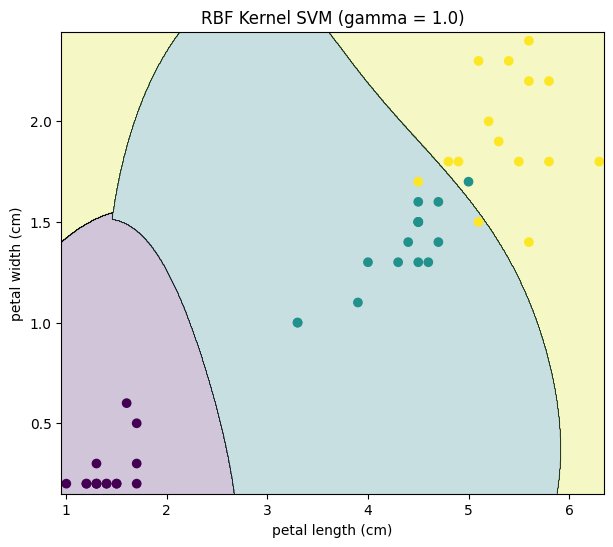

In [9]:
#TODO
gamma = 1.0

clf = SVC(kernel='rbf', C=1.0, gamma=gamma, max_iter=100000)
clf.fit(X_train, y_train)

test_accuracy = clf.score(X_test, y_test)
test_error = 1 - test_accuracy

num_support_vectors = clf.n_support_.sum()

print("Chosen gamma =", gamma)
print("Test accuracy =", test_accuracy)
print("Test error =", test_error)
print("Number of support vectors =", num_support_vectors)

plot_decision_boundary(clf, X_test, y_test)
plt.title(f"RBF Kernel SVM (gamma = {gamma})")
plt.show()


เลือก gamma = 1.0 โดยได้ค่า test error = 0.06666666666666665 และจำนวน support vectors = 25 ตัว

#### Exercise 6. Between Linear SVM and Kernel SVM, which model would you prefer to use for classification of Iris data?
1. Explain using test accuracy
2. Explaing using decision boundary plot

In [10]:
#TODO
# เปรียบเทียบ Test Accuracy
# Linear SVM
linear_clf = LinearSVC(C=1.0, loss='hinge', max_iter=100000)
linear_clf.fit(X_train, y_train)

linear_acc = linear_clf.score(X_test, y_test)

# Kernel SVM (RBF)
kernel_clf = SVC(kernel='rbf', C=1.0, gamma=1.0, max_iter=100000)
kernel_clf.fit(X_train, y_train)

kernel_acc = kernel_clf.score(X_test, y_test)

print("Linear SVM Test Accuracy:", linear_acc)
print("Kernel SVM Test Accuracy:", kernel_acc)


Linear SVM Test Accuracy: 0.6888888888888889
Kernel SVM Test Accuracy: 0.9333333333333333


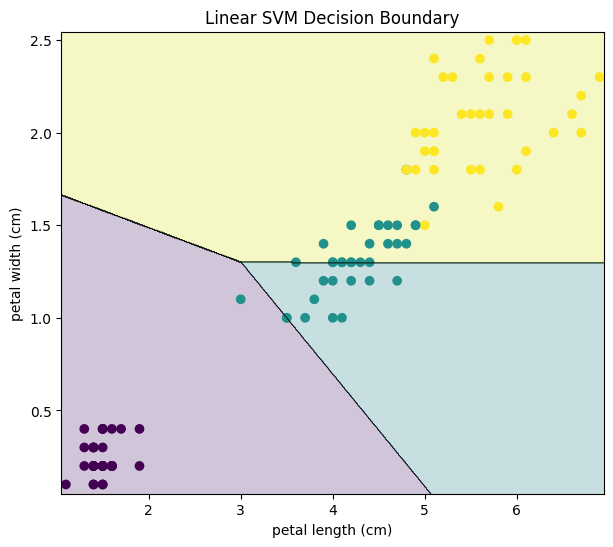

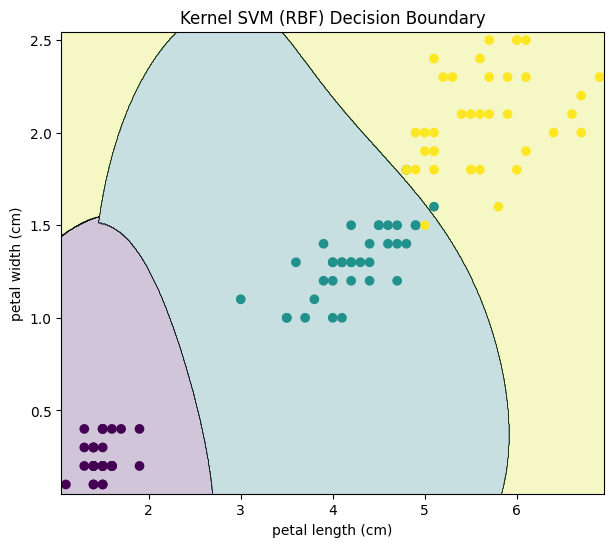

In [11]:
# Plot Decision Boundary เปรียบเทียบ
plot_decision_boundary(linear_clf, X_train, y_train)
plt.title("Linear SVM Decision Boundary")
plt.show()

plot_decision_boundary(kernel_clf, X_train, y_train)
plt.title("Kernel SVM (RBF) Decision Boundary")
plt.show()


1.Kernel SVM ให้ค่า test accuracy สูงกว่า Linear SVM แสดงว่าโมเดลสามารถเรียนรู้ความสัมพันธ์ที่ไม่เป็นเส้นตรงในข้อมูล Iris ได้ดีกว่า ทำให้สามารถจำแนกข้อมูลชุดทดสอบได้แม่นยำมากขึ้น

ในขณะที่ Linear SVM เหมาะกับข้อมูลที่สามารถแบ่งด้วยเส้นตรง แต่ข้อมูล Iris มีรูปแบบการกระจายที่ซับซ้อนและไม่เป็นเชิงเส้น จึงทำให้ Linear SVM มีความแม่นยำน้อยกว่า

2.จากกราฟ decision boundary พบว่า

-Linear SVM สร้างเส้นแบ่งเป็นเส้นตรง ทำให้บางบริเวณของข้อมูลทับซ้อนกันและถูกจำแนกผิด

-Kernel SVM สร้างเส้นแบ่งโค้งที่สอดคล้องกับการกระจายของข้อมูลมากกว่า จึงสามารถแยกกลุ่มข้อมูลได้ชัดเจนกว่า